[*********             18%                       ]  2 of 11 completed

📊 Starting Factor Rotation Backtest Engine...

🔍 Downloading price data for: ['AAPL', 'MSFT', 'GOOGL', 'META', 'TSLA', 'NVDA', 'AMZN', 'JPM', 'BRK-B', 'UNH'] plus benchmark SPY


[*********************100%***********************]  11 of 11 completed


✅ Downloaded price data with shape: (1885, 10)

⚙️ Calculating factor signals...
 - Factor signals calculated.

⚖️ Monthly ranking of stocks by factor signals computed.

📈 Running backtests for individual factors...

⚠️ Skipping rotation date 2018-02-28 00:00:00 due to error: "Cannot get left slice bound for non-unique label: Timestamp('2018-02-28 00:00:00')"
⚠️ Skipping rotation date 2018-03-31 00:00:00 due to error: Timestamp('2018-03-31 00:00:00')
⚠️ Skipping rotation date 2018-06-30 00:00:00 due to error: Timestamp('2018-06-30 00:00:00')
⚠️ Skipping rotation date 2018-09-30 00:00:00 due to error: Timestamp('2018-09-30 00:00:00')
⚠️ Skipping rotation date 2018-12-31 00:00:00 due to error: "Cannot get left slice bound for non-unique label: Timestamp('2018-12-31 00:00:00')"
⚠️ Skipping rotation date 2019-02-28 00:00:00 due to error: "Cannot get left slice bound for non-unique label: Timestamp('2019-02-28 00:00:00')"
⚠️ Skipping rotation date 2019-03-31 00:00:00 due to error: Timestamp

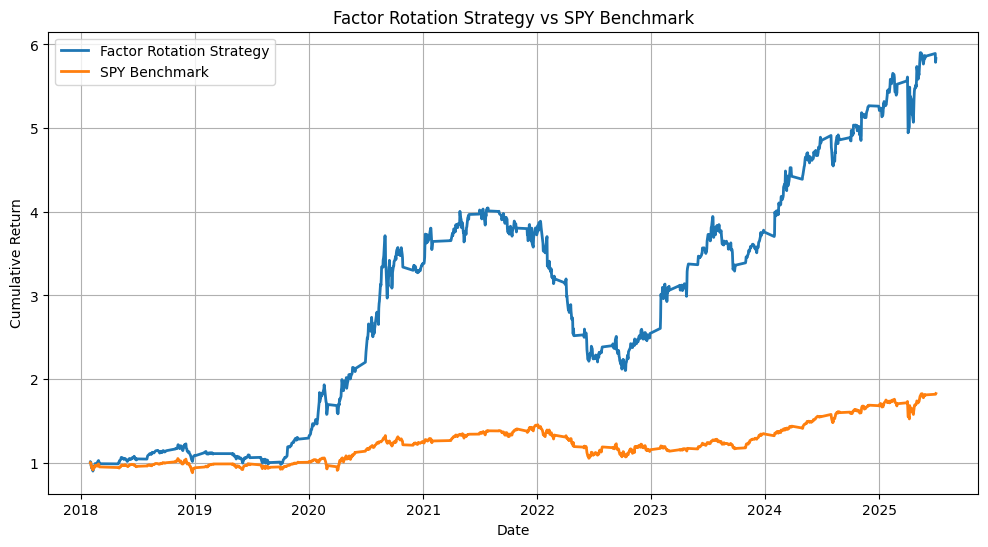


📊 Portfolio Performance Summary
----------------------------------
Total Return: 483.22% (Strategy) vs 82.72% (SPY Benchmark)
Annualized Sharpe Ratio: 1.404
Maximum Drawdown: -48.02%

Stock Picks for July 2025:

Best Performing Factor: Volatility
 - Buy these top 3 stocks: MSFT, BRK-B, JPM

Momentum Factor Top 3 Stocks:
 - Buy: NVDA, JPM, META

Volatility Factor Top 3 Stocks:
 - Buy: MSFT, BRK-B, JPM

Value Factor Top 3 Stocks:
 - Buy: JPM, BRK-B, META

Investment Approach:
- At the start of each month, sell all current holdings.
- Buy the top 3 stocks ranked highest in the best-performing factor from the prior month.
- Hold these stocks for the entire month.
- Repeat this process monthly with updated factor data.

Interpretation:
This factor rotation strategy adapts monthly to the strongest factor signals.
It targets improved risk-adjusted returns over a static buy-and-hold benchmark (SPY).
The Sharpe ratio of 1.404 shows efficient return relative to risk,
and maximum drawdown of -48

In [6]:
# 📦 Install and import packages
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

print("📊 Starting Factor Rotation Backtest Engine...\n")

# Dynamic dates for timelessness
start_date = '2018-01-01'
end_date = datetime.datetime.today().strftime('%Y-%m-%d')

# Investable stocks (exclude SPY)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'TSLA', 'NVDA', 'AMZN', 'JPM', 'BRK-B', 'UNH']
benchmark_ticker = 'SPY'

print(f"🔍 Downloading price data for: {tickers} plus benchmark {benchmark_ticker}")
raw_data = yf.download(tickers + [benchmark_ticker], start=start_date, end=end_date, group_by='ticker', auto_adjust=False)

# Price data
data = pd.DataFrame({ticker: raw_data[ticker]['Adj Close'] for ticker in tickers}).dropna()
benchmark_data = raw_data[benchmark_ticker]['Adj Close'].dropna()

print(f"✅ Downloaded price data with shape: {data.shape}\n")

returns = data.pct_change().dropna()
benchmark_returns = benchmark_data.pct_change().dropna()

print("⚙️ Calculating factor signals...")

momentum = data.pct_change(21)  # 1-month momentum
volatility = returns.rolling(21).std()  # 1-month volatility

# Static P/E ratios for value factor (mock)
pe_ratios = {
    'AAPL': 28, 'MSFT': 32, 'GOOGL': 25, 'META': 20, 'TSLA': 70,
    'NVDA': 45, 'AMZN': 80, 'JPM': 11, 'BRK-B': 18, 'UNH': 20
}
value = pd.DataFrame(index=data.index, columns=pe_ratios.keys())
for stock in value.columns:
    value[stock] = 1 / pe_ratios[stock]

print(" - Factor signals calculated.\n")

# Monthly rank helper
def rank_factor(factor_df, ascending=False):
    return factor_df.resample('M').last().rank(axis=1, ascending=ascending)

momentum_rank = rank_factor(momentum, ascending=False)
volatility_rank = rank_factor(volatility, ascending=True)
value_rank = rank_factor(value, ascending=False)

print("⚖️ Monthly ranking of stocks by factor signals computed.\n")

# Backtest individual factors
def backtest_factor(rank_df, returns_df, top_n=3):
    monthly_rets = []
    for date in rank_df.index:
        if date not in returns_df.index:
            continue
        top_stocks = rank_df.loc[date].nsmallest(top_n).index
        try:
            window = returns_df[top_stocks].loc[date:].iloc[:21]
            monthly_ret = window.mean(axis=1)
            monthly_rets.append(monthly_ret)
        except Exception as e:
            print(f"⚠️ Skipping {date} due to error: {e}")
            continue
    return pd.concat(monthly_rets)

print("📈 Running backtests for individual factors...\n")

momentum_perf = backtest_factor(momentum_rank, returns)
volatility_perf = backtest_factor(volatility_rank, returns)
value_perf = backtest_factor(value_rank, returns)

monthly_returns = pd.DataFrame({
    'Momentum': momentum_perf.resample('M').sum(),
    'Volatility': volatility_perf.resample('M').sum(),
    'Value': value_perf.resample('M').sum()
}).dropna()

best_factor = monthly_returns.idxmax(axis=1)

# Rotation strategy returns build
strategy_returns = []
for date, factor in best_factor.items():
    try:
        if factor == 'Momentum':
            r = momentum_perf.loc[date:].iloc[:21]
        elif factor == 'Volatility':
            r = volatility_perf.loc[date:].iloc[:21]
        else:
            r = value_perf.loc[date:].iloc[:21]
        strategy_returns.append(r)
    except Exception as e:
        print(f"⚠️ Skipping rotation date {date} due to error: {e}")

rotation_returns = pd.concat(strategy_returns)
rotation_returns = rotation_returns.loc[~rotation_returns.index.duplicated()]

rotation_cum = (rotation_returns + 1).cumprod()
benchmark_cum = (benchmark_returns.loc[rotation_cum.index] + 1).cumprod()

# Plot cumulative returns
plt.figure(figsize=(12,6))
plt.plot(rotation_cum, label='Factor Rotation Strategy', linewidth=2)
plt.plot(benchmark_cum, label='SPY Benchmark', linewidth=2)
plt.title('Factor Rotation Strategy vs SPY Benchmark')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

# Performance metrics
def sharpe_ratio(returns, rf=0.0):
    return (returns.mean() - rf) / returns.std() * np.sqrt(252)

def max_drawdown(cum_returns):
    roll_max = cum_returns.cummax()
    drawdown = (cum_returns - roll_max) / roll_max
    return drawdown.min()

sharpe = sharpe_ratio(rotation_returns)
drawdown = max_drawdown(rotation_cum)
total_return = rotation_cum.iloc[-1] - 1
benchmark_return = benchmark_cum.iloc[-1] - 1

print("\n📊 Portfolio Performance Summary")
print("-" * 34)
print(f"Total Return: {total_return:.2%} (Strategy) vs {benchmark_return:.2%} (SPY Benchmark)")
print(f"Annualized Sharpe Ratio: {sharpe:.3f}")
print(f"Maximum Drawdown: {drawdown:.2%}\n")

# === New: Show current month’s stock picks ===
current_month = best_factor.index[-1]
current_best_factor = best_factor.iloc[-1]

def get_top_stocks_for_factor(factor_name, date, top_n=3):
    if factor_name == 'Momentum':
        ranks = momentum_rank.loc[date]
    elif factor_name == 'Volatility':
        ranks = volatility_rank.loc[date]
    elif factor_name == 'Value':
        ranks = value_rank.loc[date]
    else:
        return []
    return ranks.nsmallest(top_n).index.tolist()

print(f"Stock Picks for {current_month.strftime('%B %Y')}:\n")

# Overall best factor picks
overall_stocks = get_top_stocks_for_factor(current_best_factor, current_month)
print(f"Best Performing Factor: {current_best_factor}")
print(f" - Buy these top 3 stocks: {', '.join(overall_stocks)}\n")

# Momentum picks
momentum_stocks = get_top_stocks_for_factor('Momentum', current_month)
print(f"Momentum Factor Top 3 Stocks:")
print(f" - Buy: {', '.join(momentum_stocks)}\n")

# Volatility picks
volatility_stocks = get_top_stocks_for_factor('Volatility', current_month)
print(f"Volatility Factor Top 3 Stocks:")
print(f" - Buy: {', '.join(volatility_stocks)}\n")

# Value picks
value_stocks = get_top_stocks_for_factor('Value', current_month)
print(f"Value Factor Top 3 Stocks:")
print(f" - Buy: {', '.join(value_stocks)}\n")

print("Investment Approach:")
print("- At the start of each month, sell all current holdings.")
print("- Buy the top 3 stocks ranked highest in the best-performing factor from the prior month.")
print("- Hold these stocks for the entire month.")
print("- Repeat this process monthly with updated factor data.\n")

print("Interpretation:")
print("This factor rotation strategy adapts monthly to the strongest factor signals.")
print("It targets improved risk-adjusted returns over a static buy-and-hold benchmark (SPY).")
print(f"The Sharpe ratio of {sharpe:.3f} shows efficient return relative to risk,")
print(f"and maximum drawdown of {drawdown:.2%} reflects controlled downside exposure.\n")

print("Note:")
print("Backtest results exclude transaction costs and slippage, which may impact real-world outcomes.")
print("Further validation and gradual implementation are advised before deploying real capital.\n")
